In [131]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
data = pd.read_csv("dataset.csv")
data.head()

,ID,Store_id,Store_Type,Location_Type,Region_Code,Date,Holiday,Discount,#Order,Sales
0,T1000001,1,S1,L3,R1,2018-01-01,1,Yes,9,7011.84
1,T1000002,253,S4,L2,R1,2018-01-01,1,Yes,60,51789.12
2,T1000003,252,S3,L2,R1,2018-01-01,1,Yes,42,36868.20
3,T1000004,251,S2,L3,R1,2018-01-01,1,Yes,23,19715.16
4,T1000005,250,S2,L3,R4,2018-01-01,1,Yes,62,45614.52


In [132]:
data.isnull().sum()

ID               0
Store_id         0
Store_Type       0
Location_Type    0
Region_Code      0
Date             0
Holiday          0
Discount         0
#Order           0
Sales            0
dtype: int64

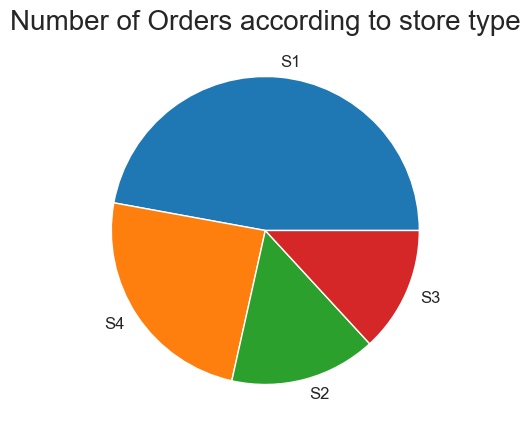

In [133]:
a = data["Store_Type"].value_counts()
index = a.index
Store_types = a.values
plt.figure(figsize=(5, 5))
plt.pie(Store_types, labels=index)
plt.rc('font', size=12)
plt.title("Number of Orders according to store type", fontsize=20)
plt.show()

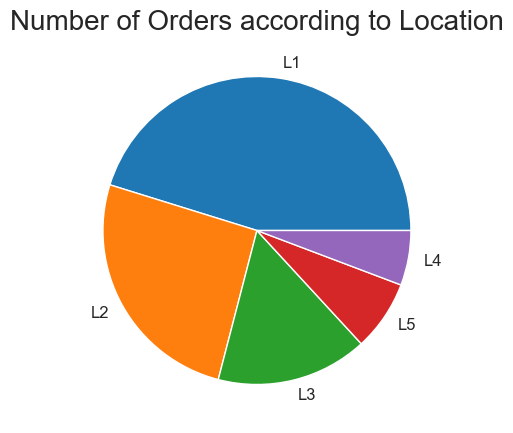

In [134]:
a = data["Location_Type"].value_counts()
index = a.index
Location = a.values
plt.figure(figsize=(5, 5))
plt.pie(Location, labels=index)
plt.rc('font', size=12)
plt.title("Number of Orders according to Location", fontsize=20)
plt.show()

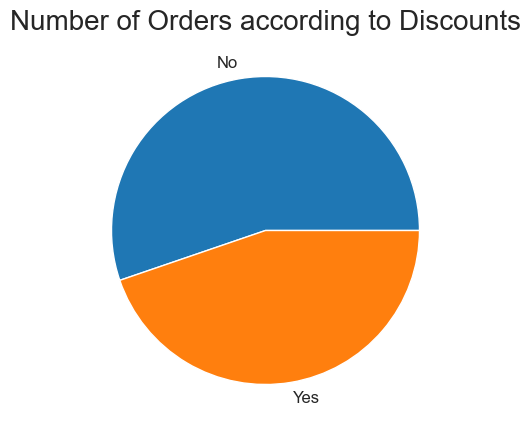

In [135]:
a = data["Discount"].value_counts()
index = a.index
Discount = a.values
plt.figure(figsize=(5, 5))
plt.pie(Discount, labels=index)
plt.rc('font', size=12)
plt.title("Number of Orders according to Discounts", fontsize=20)
plt.show()

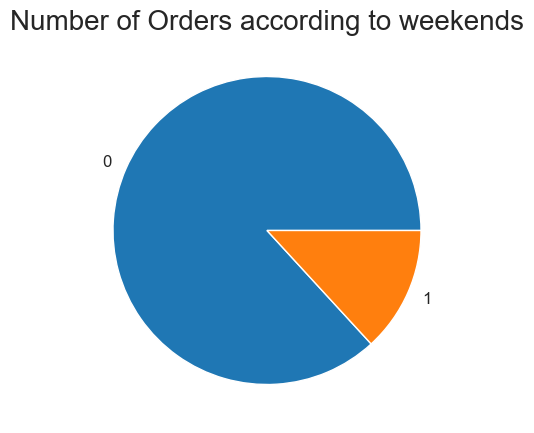

In [136]:

a = data["Holiday"].value_counts()

index = a.index
Holiday = a.values
plt.figure(figsize=(5, 5))
plt.pie(Holiday, labels=index)
plt.rc('font', size=12)
plt.title("Number of Orders according to weekends", fontsize=20)
plt.show()

In [137]:
data["Discount"] = data["Discount"].map({"No": 0, "Yes": 1})
data["Store_Type"] = data["Store_Type"].map({"S1": 1, "S2": 2, "S3": 3, "S4": 4})
data["Location_Type"] = data["Location_Type"].map({"L1": 1, "L2": 2, "L3": 3, "L4": 4, "L5": 5})
data.dropna()

x = np.array(data[["Store_Type", "Location_Type", "Holiday", "Discount"]])
y = np.array(data["#Order"])

In [138]:
from sklearn.model_selection import train_test_split
xtrain, xtest, ytrain, ytest = train_test_split(x, 
                                                y, test_size=0.2,
                                                random_state=42)

In [139]:
import lightgbm as ltb
model = ltb.LGBMRegressor()
model.fit(xtrain, ytrain)

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.637630 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 15
[LightGBM] [Info] Number of data points in the train set: 150672, number of used features: 4
[LightGBM] [Info] Start training from score 68.163401


,boosting_type,'gbdt'
,num_leaves,31
,max_depth,-1
,learning_rate,0.1
,n_estimators,100
,subsample_for_bin,200000
,objective,None
,class_weight,None
,min_split_gain,0.0
,min_child_weight,0.001
,min_child_samples,20


In [140]:
ypred = model.predict(xtest)
data = pd.DataFrame(data={"Predicted Orders": ypred.flatten()})
print(data.head())

C:\Users\user\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


   Predicted Orders
0         47.351897
1         97.068717
2         66.577788
3         85.143083
4         54.451098
